In [5]:
import sys
from pathlib import Path
import os
# notebooks → deep
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)

import numpy as np
import pandas as pd


from core.utils import load_run_data

algs = ['cov_lstd', 'cov_net', 'cov_dual_lstd', 'rnd_lstd', 'rnd']
suffixes = ['2_9_clip_long', '2_9_clip_long' ,'2_9_clip_long', '2_9_clip_long_higher_beta', '2_9_clip_long_higher_beta']
runs = []
# for i, alg in enumerate(algs):
#     runs.append(f"{alg}/{suffixes[i]}")
    
from core.configs import CONFIG_REGISTRY
CONFIG_REGISTRY

envs = []
for k, v in CONFIG_REGISTRY.items():
    v['envs']
    envs += v['envs']
envs

PROJECT_ROOT: /usr/project/xtmp/ds541/td-avar-explore/deep


['DiscountingChain-bsuite',
 'BernoulliBandit-misc',
 'GaussianBandit-misc',
 'MetaMaze-misc',
 'CartPole-v1',
 'Acrobot-v1',
 'UmbrellaChain-bsuite',
 'Reacher-misc',
 'PointRobot-misc',
 'Swimmer-misc',
 'Pong-misc',
 'FourRooms-misc',
 'MNISTBandit-bsuite',
 'Catch-bsuite',
 'SparseMountainCar-v0',
 'DeepSea-bsuite',
 'SpaceInvaders-MinAtar',
 'Breakout-MinAtar',
 'Freeway-MinAtar',
 'Asterix-MinAtar']

NameError: name 'metrics' is not defined

Saved plot: ../figures/cov_variants_vi.pdf
Saved plot: ../figures/cov_variants_ri.pdf
Saved plot: ../figures/cov_variants_lambda_s.pdf
Saved plot: ../figures/cov_variants_lambda_s.pdf
Saved plot: ../figures/cov_variants_lambda_s.pdf


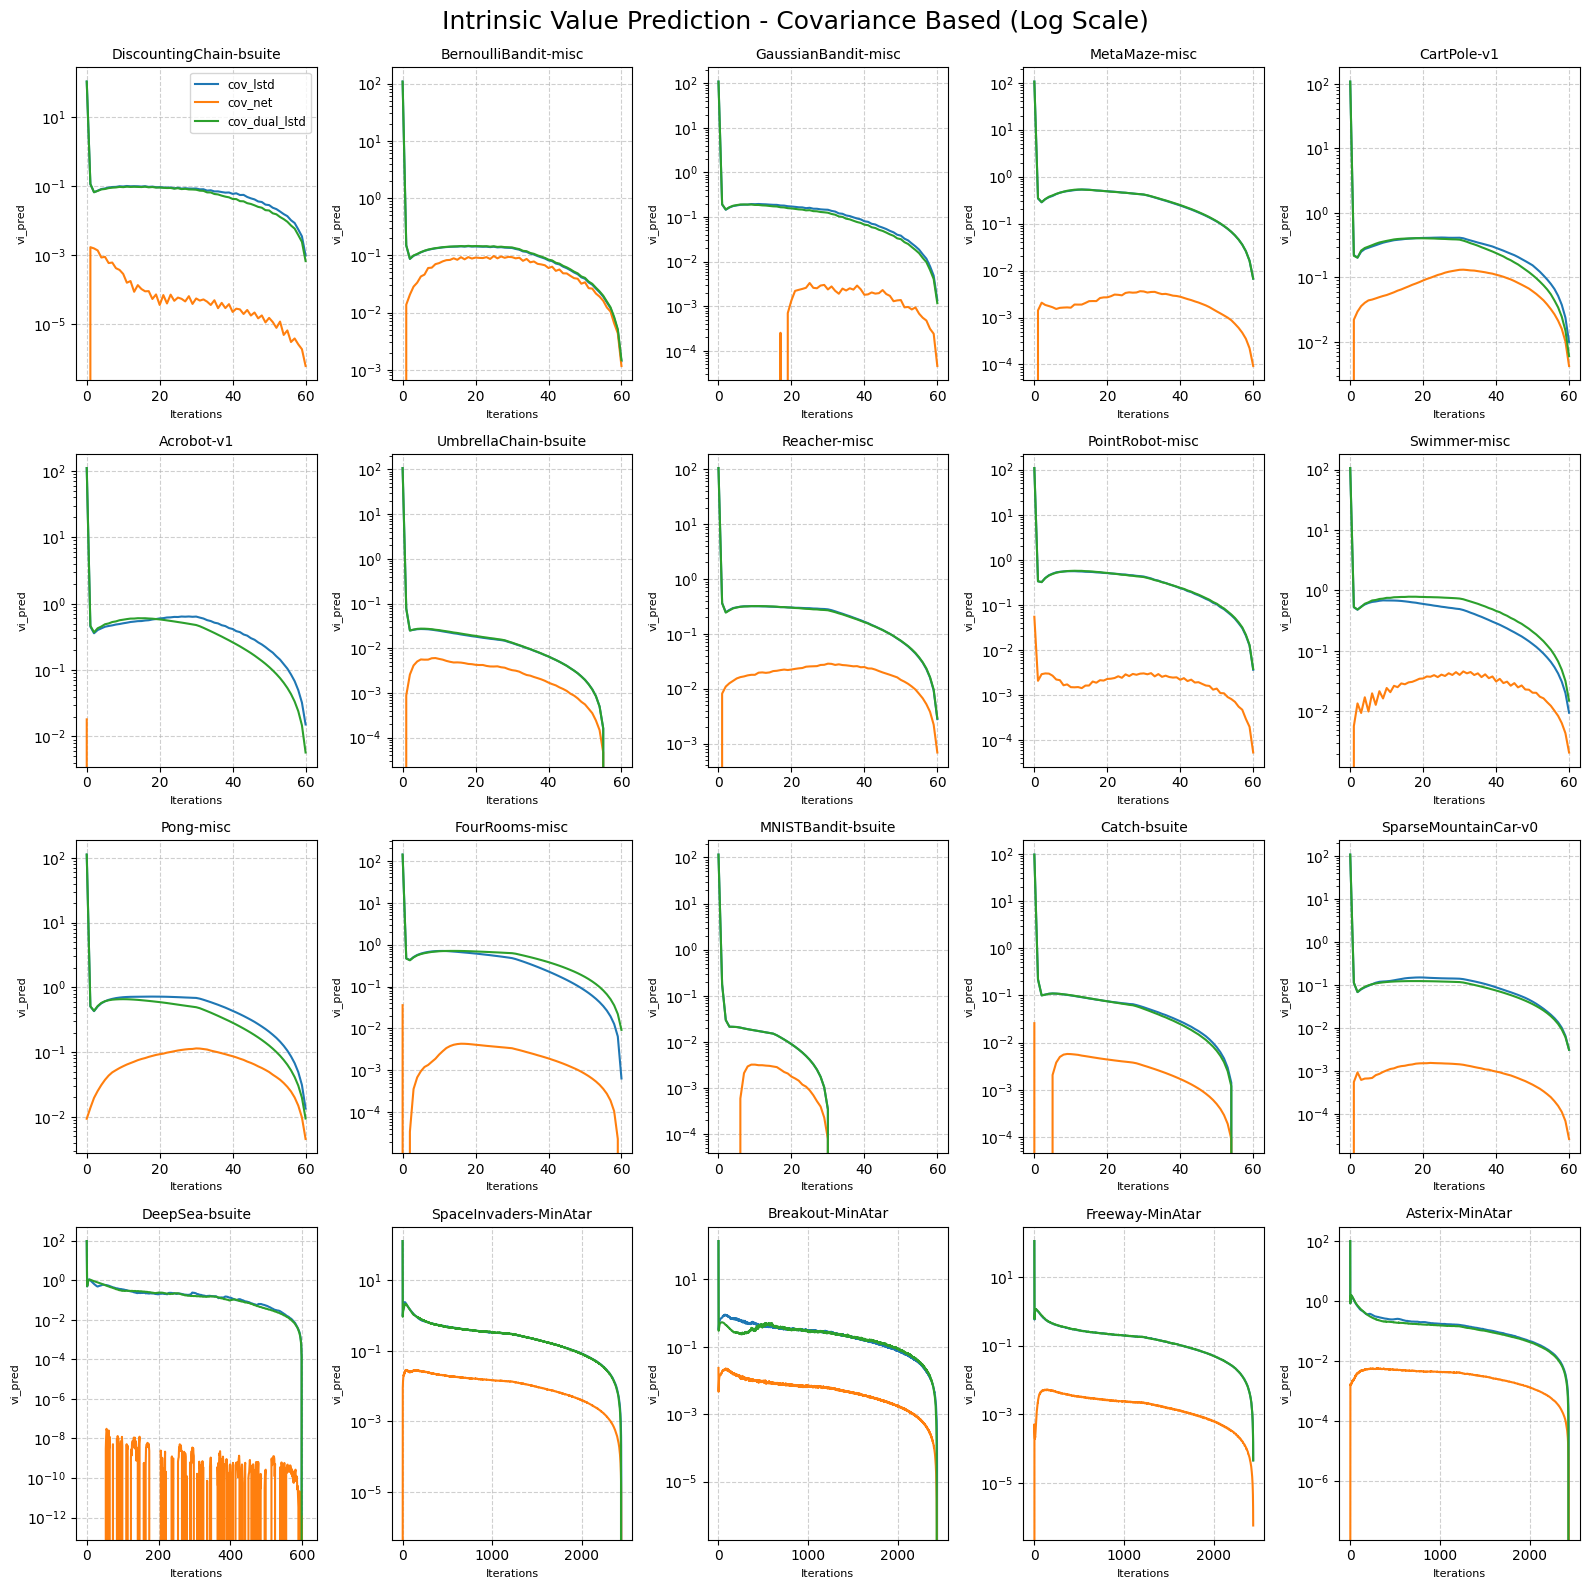

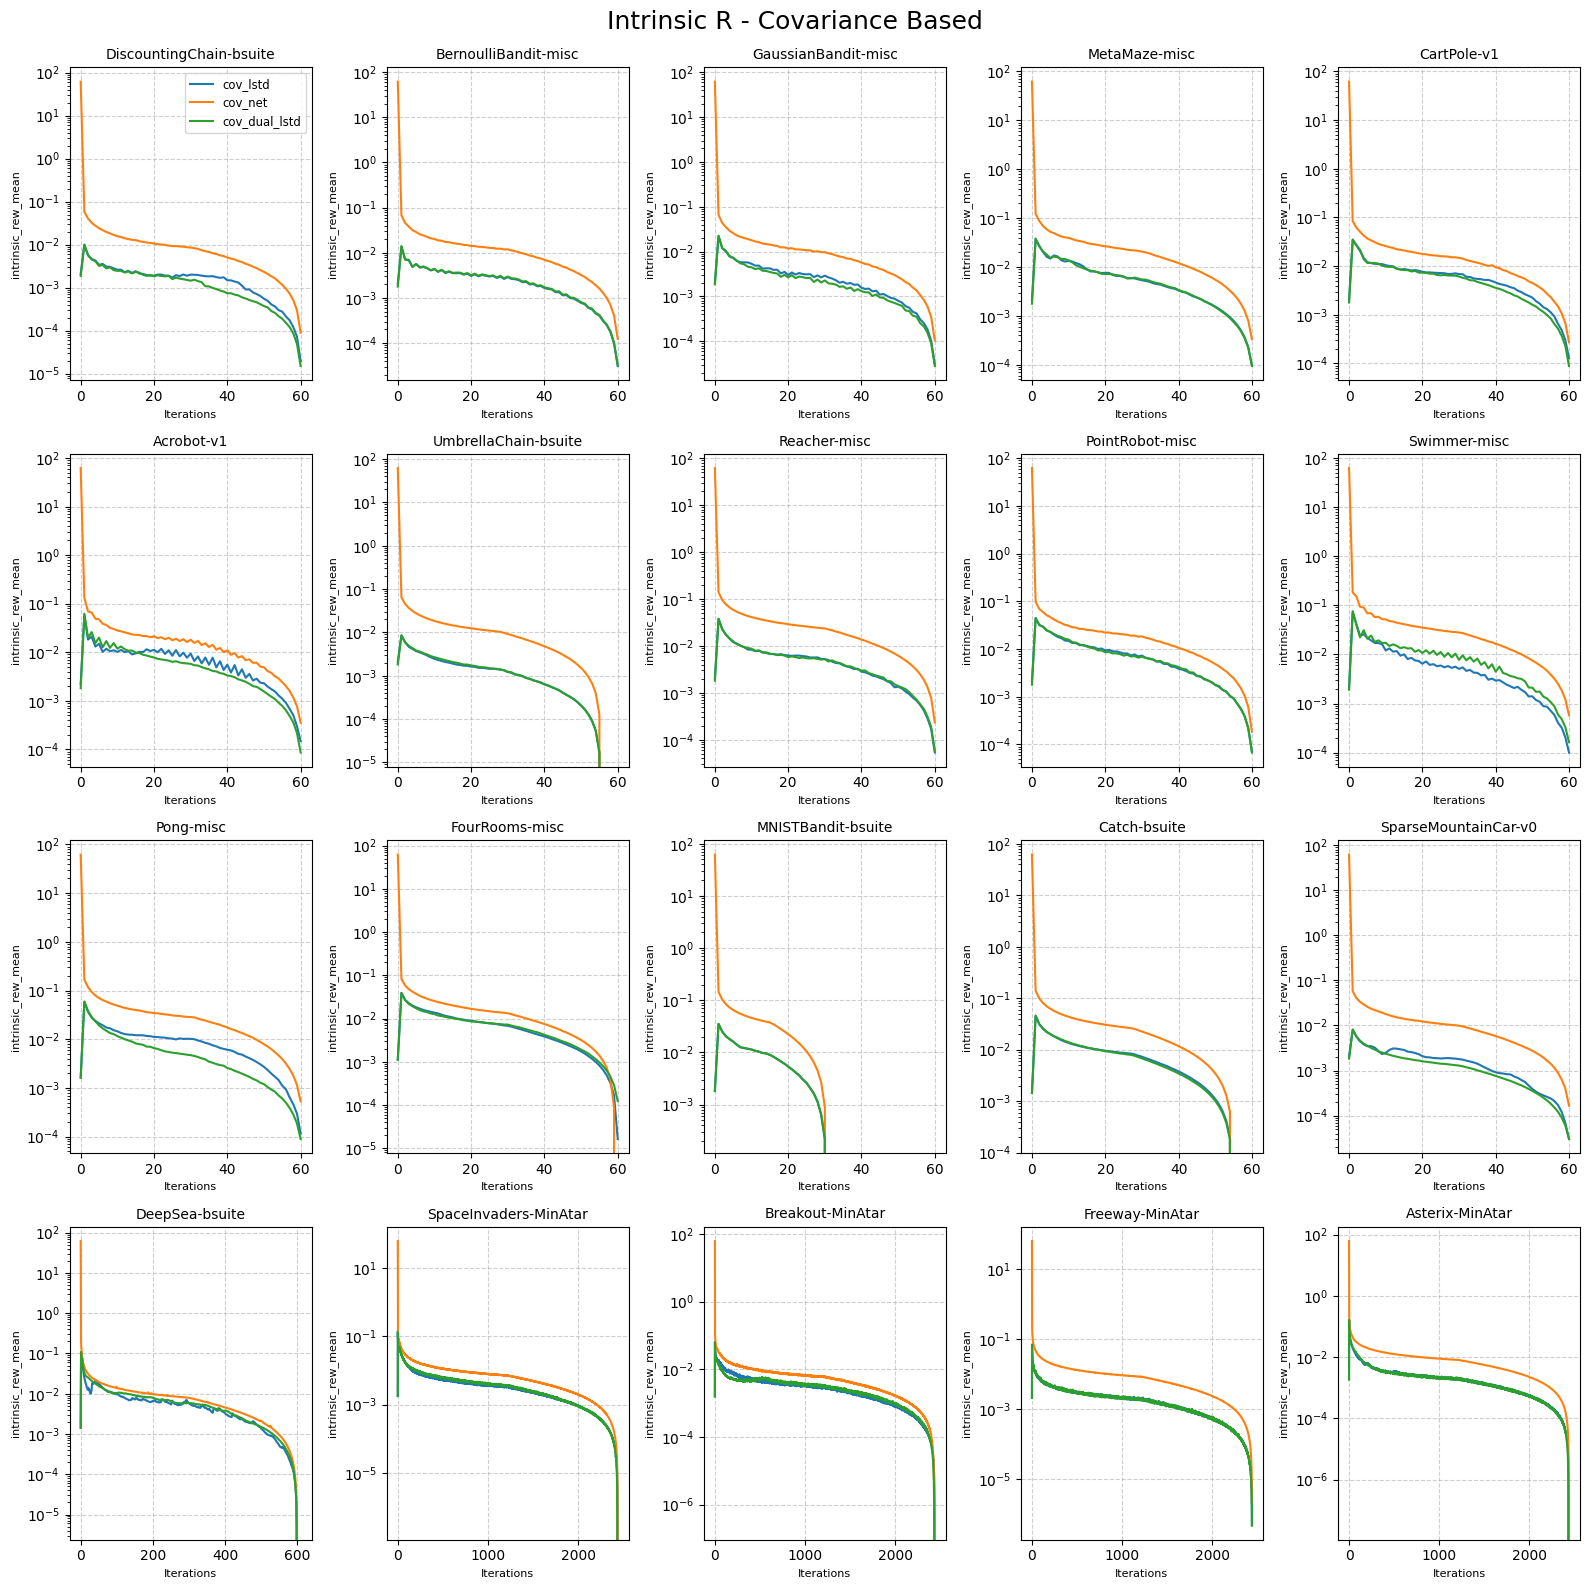

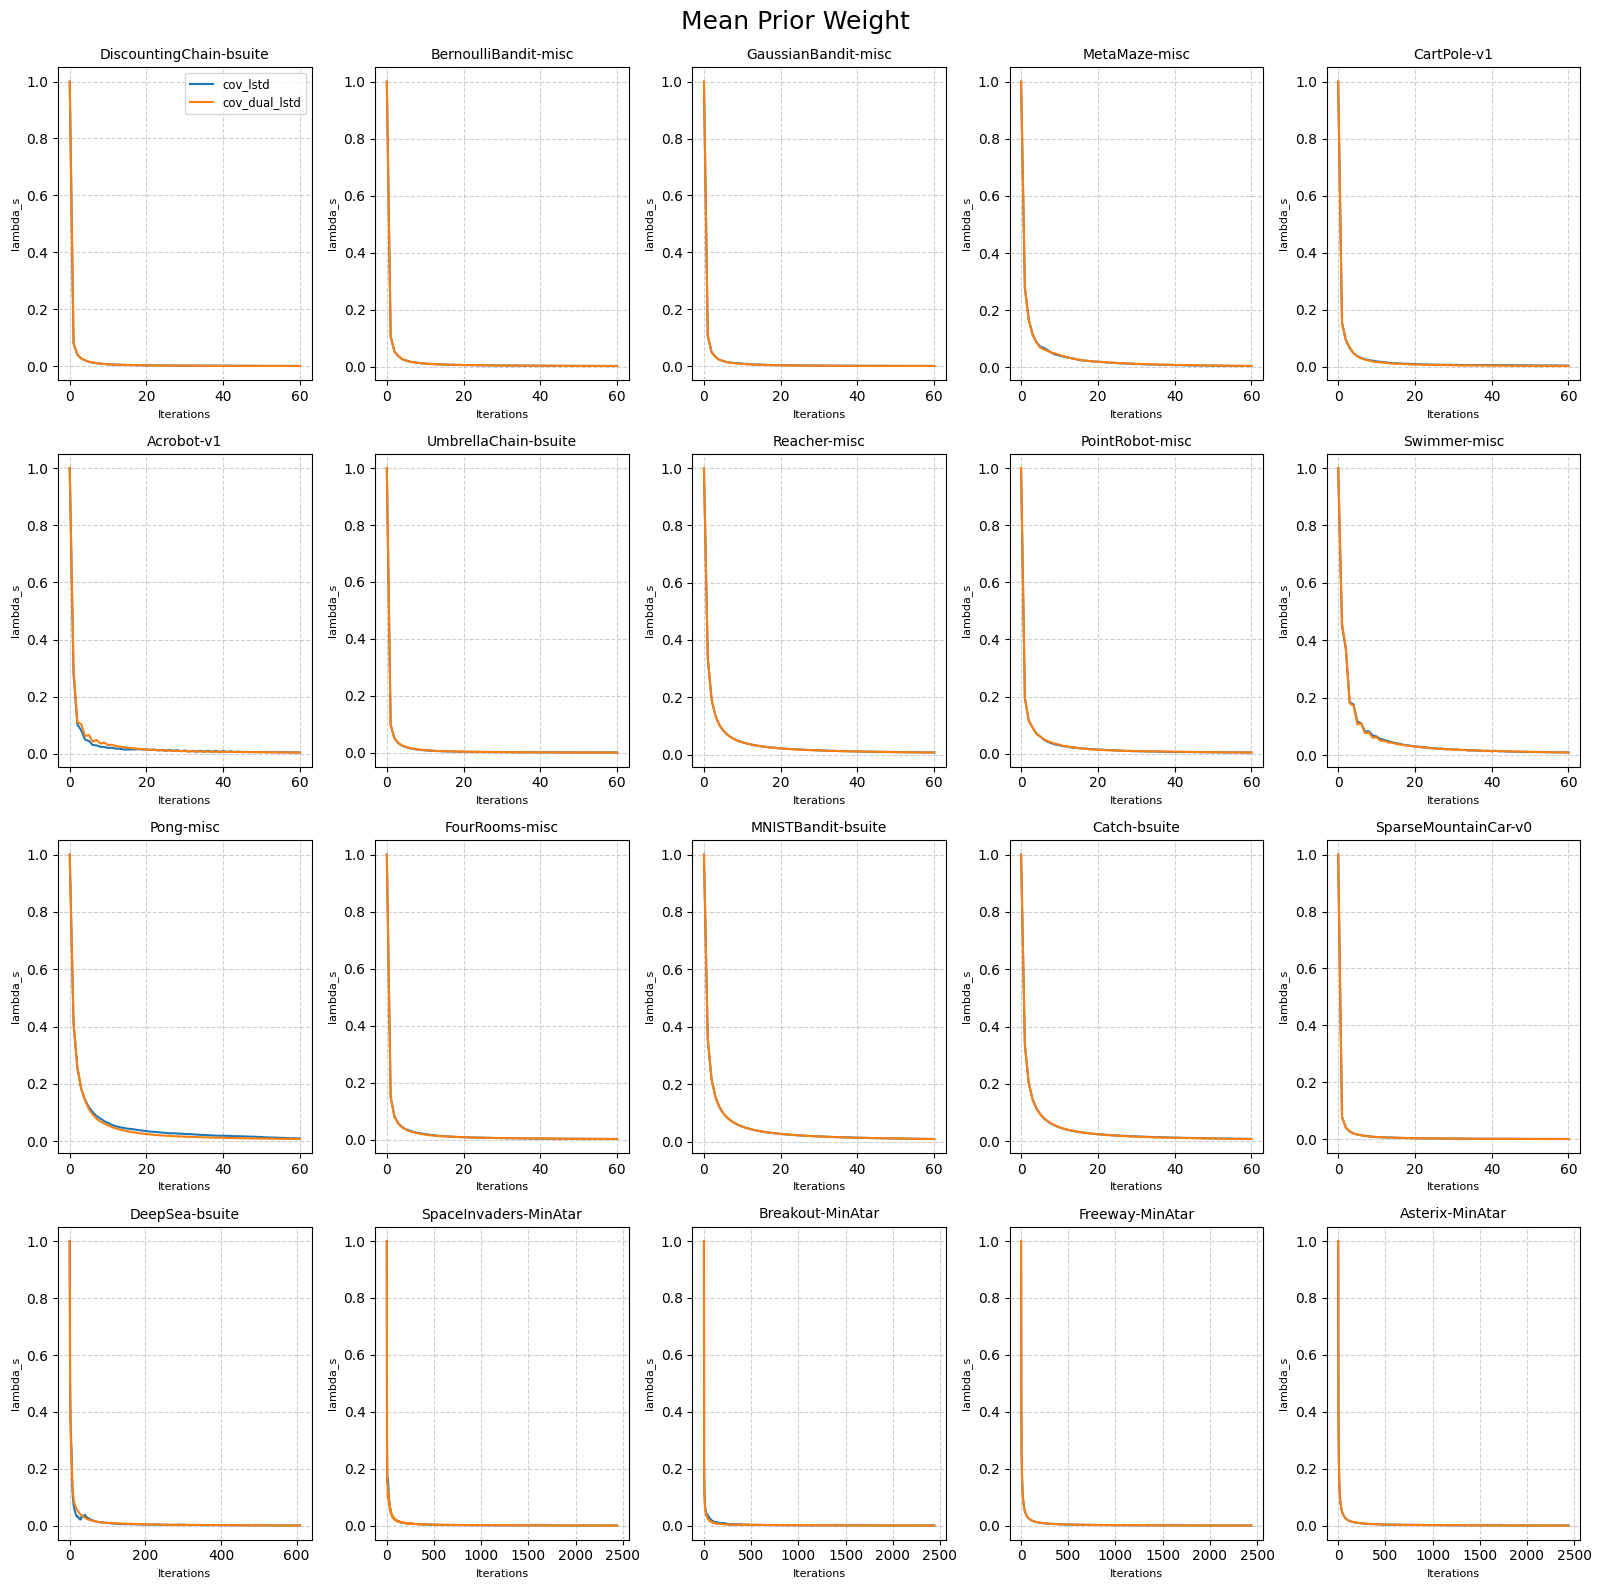

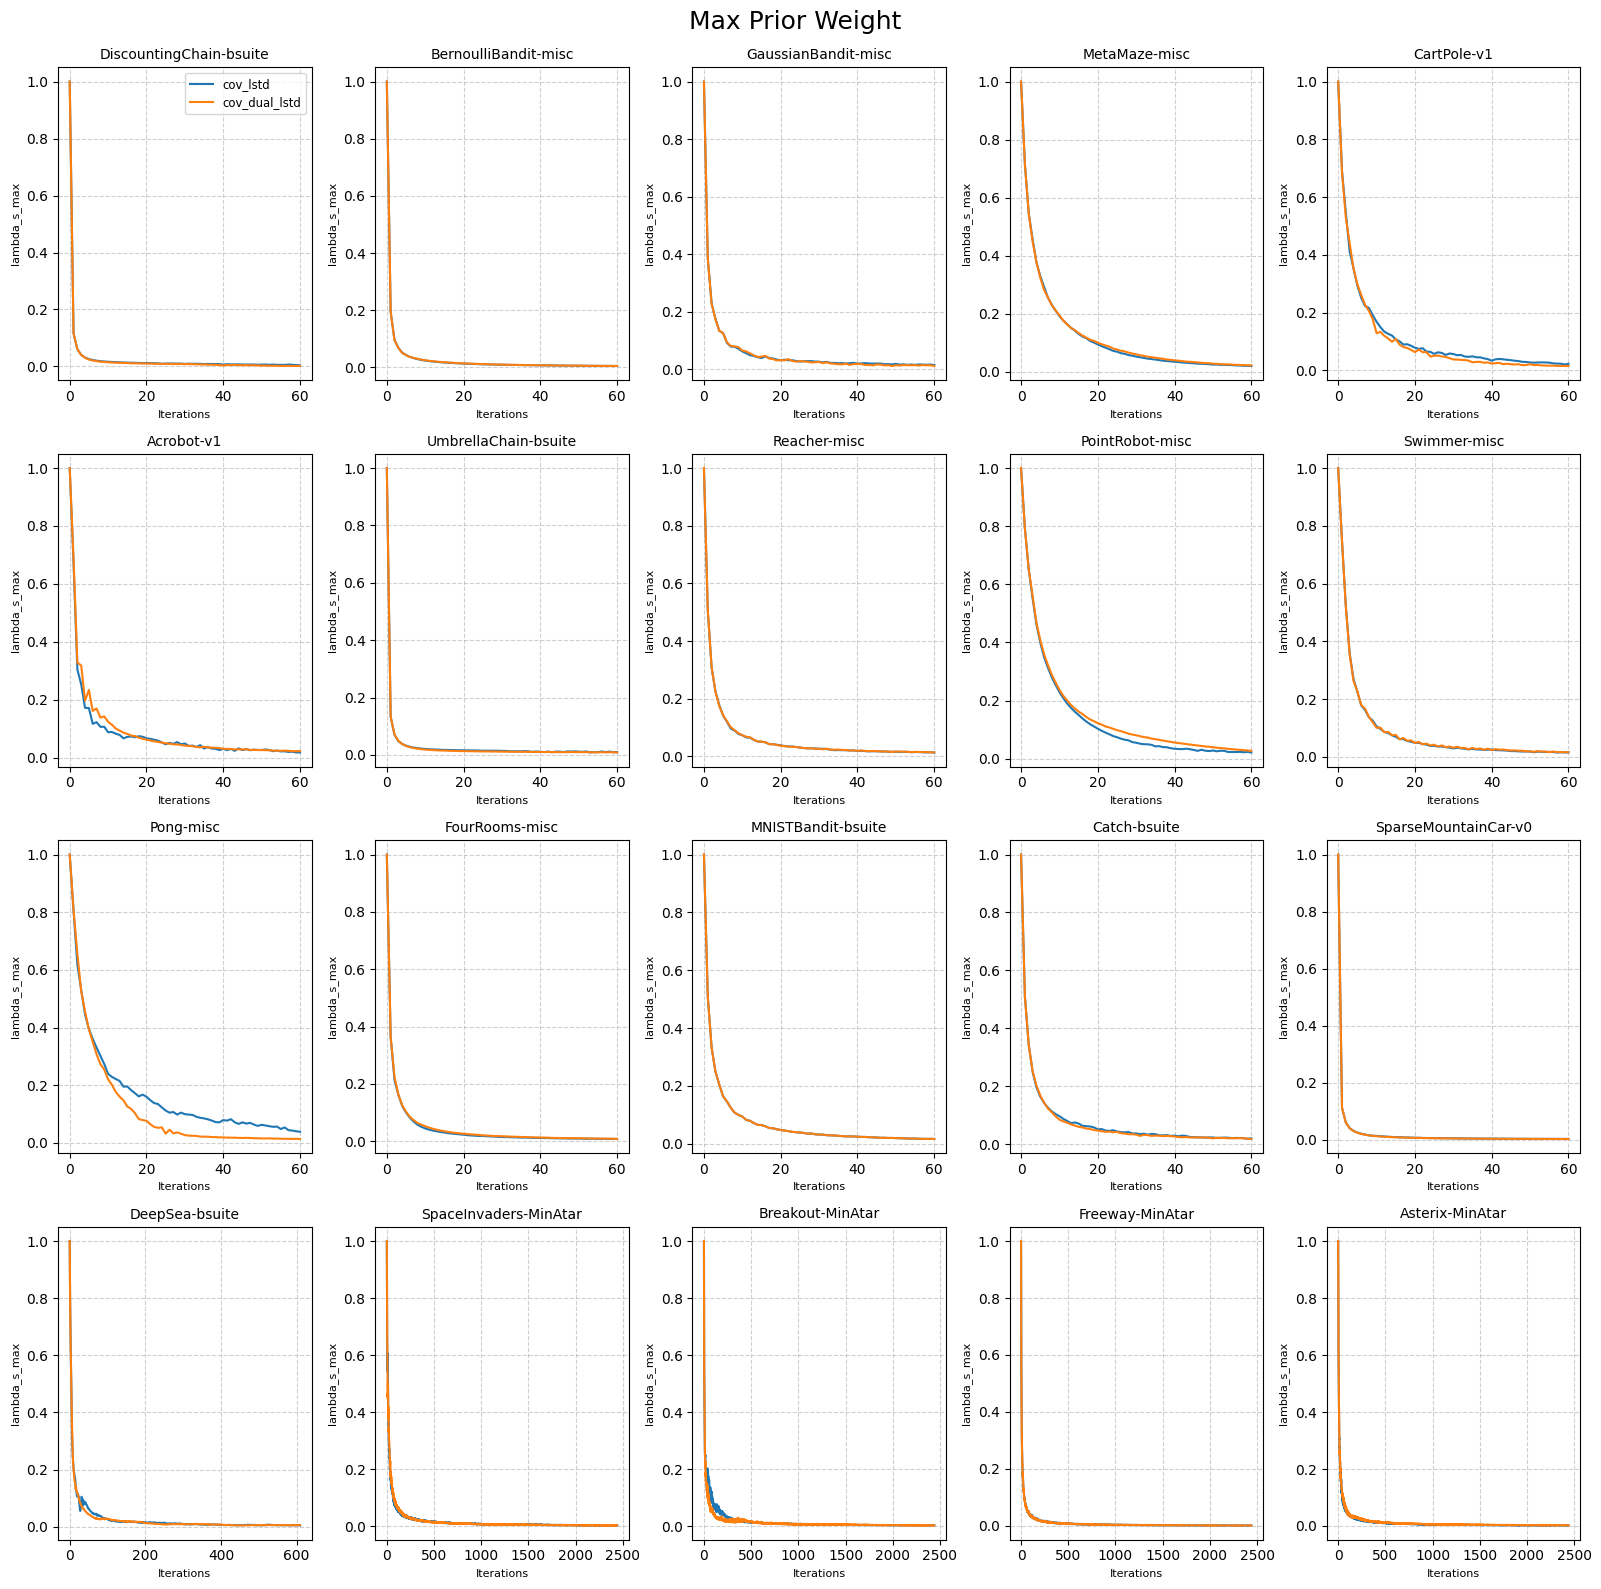

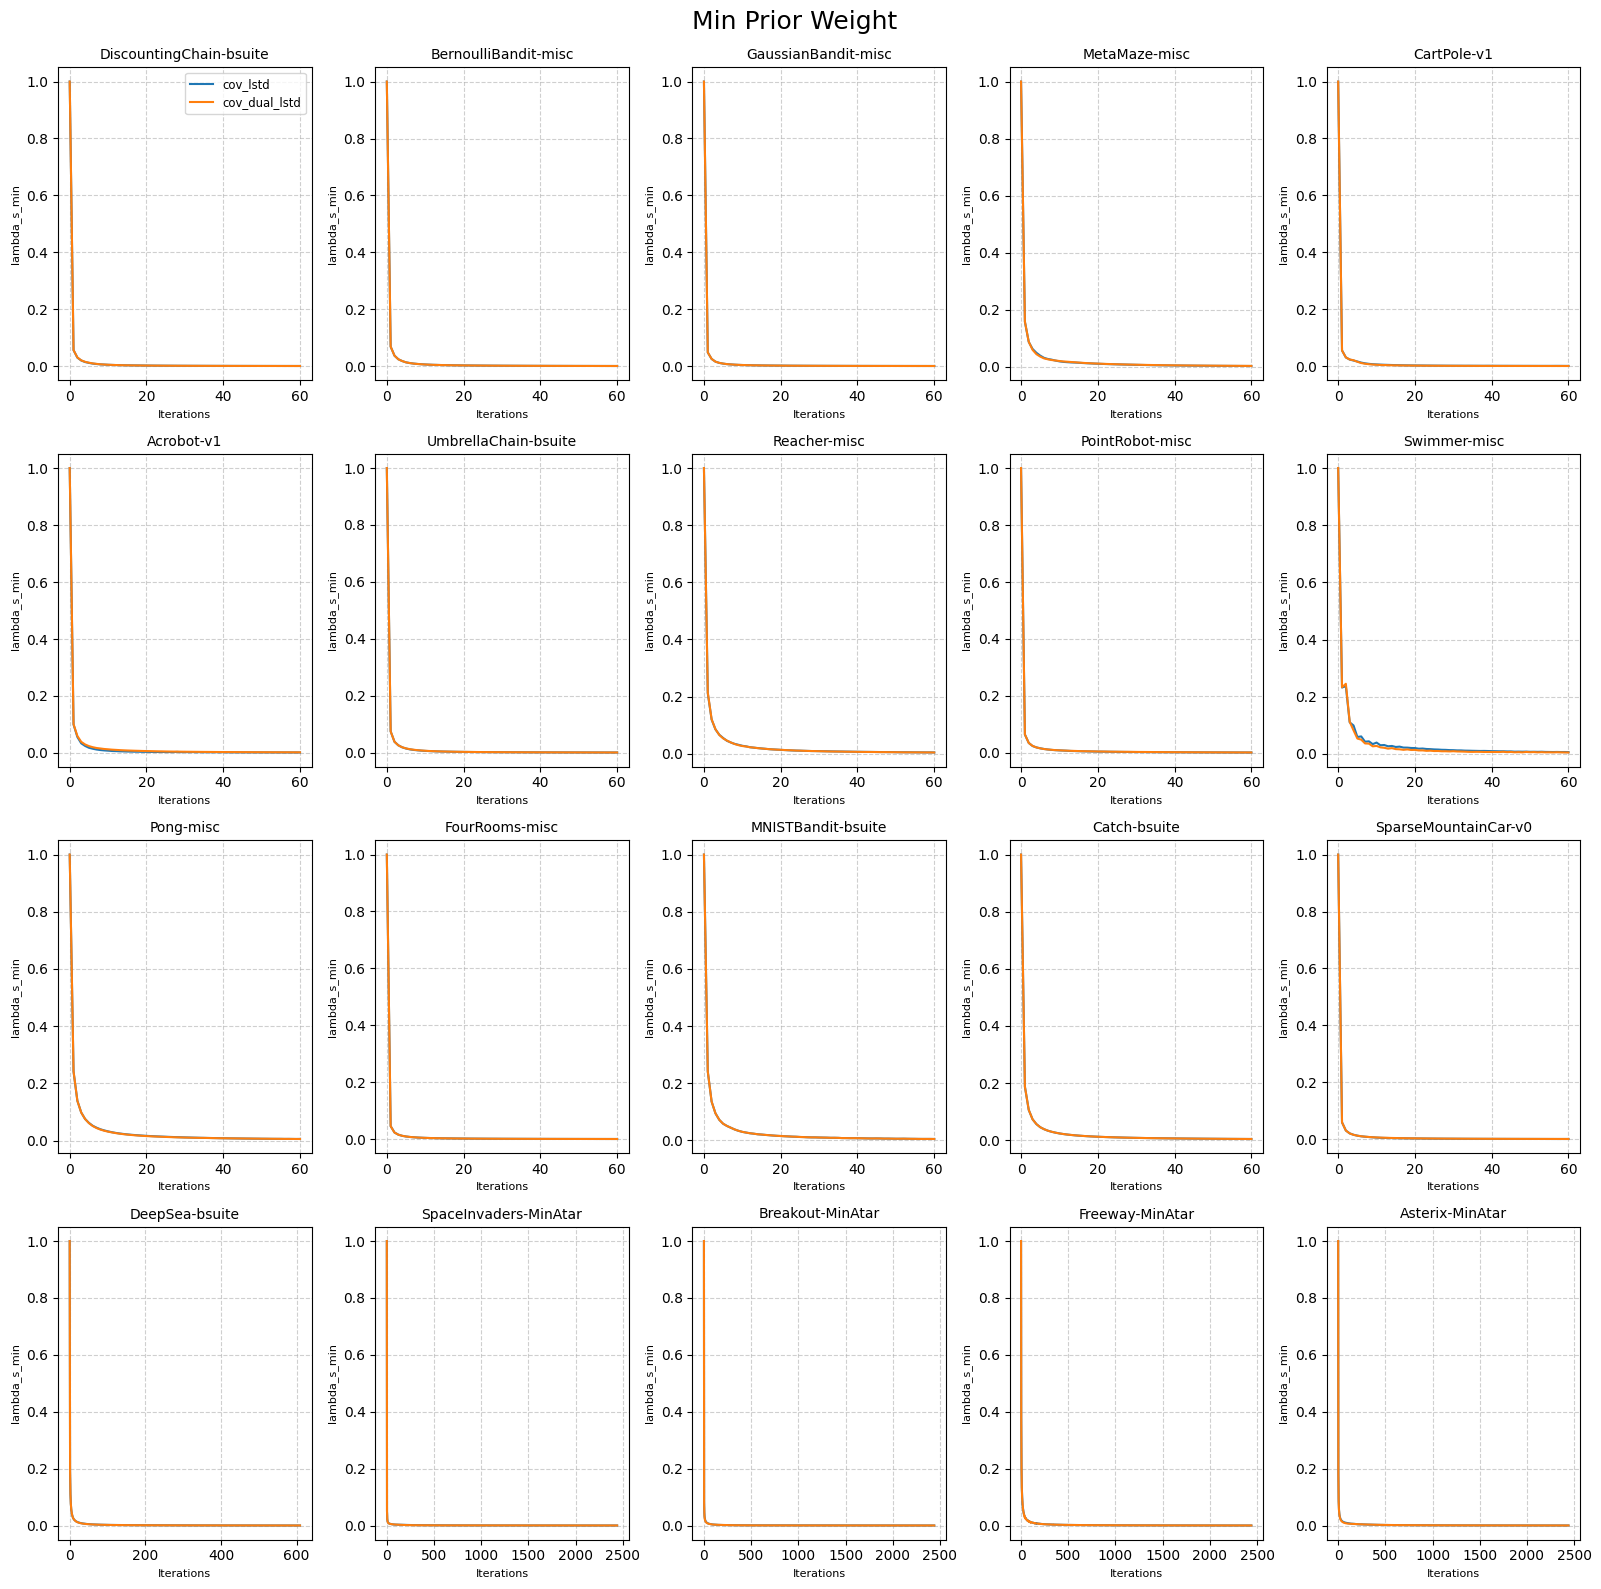

In [12]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Setup paths (Assuming execution from a notebook in a sub-directory)
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from core.utils import load_run_data
from core.configs import CONFIG_REGISTRY

def main():

    set_1_algs = algs[:3]
    set_2_algs = algs[3:]
    
    # 2. Extract Environments from Registry
    envs = []
    for k, v in CONFIG_REGISTRY.items():
        if 'envs' in v:
            envs += v['envs']
    
    # Maintain order and ensure we have exactly 20 for the 5x4 grid
    envs = list(dict.fromkeys(envs))[:20] 

    def plot_learning_sets(alg_list, title_prefix, file_name, metric = 'returned_discounted_episode_returns', logscale = False):
        """Generates a 5x4 grid of learning curves for a given set of algorithms."""
        fig, axes = plt.subplots(4, 5, figsize=(16, 16))
        axes = axes.flatten()
        
        for i, env in enumerate(envs):
            ax = axes[i]
            for j, alg in enumerate(alg_list):
                try:
                    # Construct path and load data
                    # run_path = runs[j]
                    suffix = "2_9_clip_long_higher_beta"
                    run_path = os.path.join(alg, suffix)
                    _, metrics = load_run_data(run_path, env)
                    
                    if metrics is not None and metric in metrics:
                        # Plot the mean across seeds as requested: metrics[...].mean(0)
                        mean_curve = metrics[metric].mean(0)
                        ax.plot(mean_curve, label=alg)
                        if logscale:
                            ax.set_yscale('log')
                except Exception:
                    continue
            
            ax.set_title(env, fontsize=10)
            ax.set_xlabel('Iterations', fontsize=8)
            ax.set_ylabel(metric, fontsize=8)
            ax.grid(True, linestyle='--', alpha=0.6)
            if i == 0:
                ax.legend(fontsize='small')
        
        plt.suptitle(f"{title_prefix}", fontsize=18, y=0.99)
        plt.tight_layout()
        plt.savefig(file_name)
        print(f"Saved plot: {file_name}")

    # --- Task 1: Plot Learning Curves ---
    # # Set 1: Cov variants
    # plot_learning_sets(set_1_algs, "Covariance Based Intrinsic Reward (Discounted Return)", "../figures/cov_variants_learning.pdf")
    
    # # Set 2: RND variants
    # plot_learning_sets(set_2_algs, "RND Based Intrinsic Reward Variants (Discounted Return)", "../figures/rnd_variants_learning.pdf")

    # plot_learning_sets(set_1_algs, "Covariance Based Intrinsic Reward (Undiscounted Return)", "../figures/cov_variants_learning_undiscounted.pdf", 'returned_episode_returns')
    
    # # Set 2: RND variants
    # plot_learning_sets(set_2_algs, "RND Based Intrinsic Reward Variants (Undiscounted Return)", "../figures/rnd_variants_learning_undiscounted.pdf", 'returned_episode_returns')

    plot_learning_sets(set_1_algs, "Intrinsic Value Prediction - Covariance Based (Log Scale)", "../figures/cov_variants_vi.pdf", 'vi_pred', logscale=True)

    
    # Set 2: RND variants
    # plot_learning_sets(set_2_algs, "Intrinsic Value Prediction - RND Based", "../figures/rnd_variants_vi.pdf", 'vi_pred',  logscale=True)


    plot_learning_sets(set_1_algs, "Intrinsic R - Covariance Based", "../figures/cov_variants_ri.pdf", 'intrinsic_rew_mean', logscale=True)
    plot_learning_sets(set_1_algs, "Mean Prior Weight", "../figures/cov_variants_lambda_s.pdf", 'lambda_s', logscale=False)
    plot_learning_sets(set_1_algs, "Max Prior Weight", "../figures/cov_variants_lambda_s.pdf", 'lambda_s_max', logscale=False)
    plot_learning_sets(set_1_algs, "Min Prior Weight", "../figures/cov_variants_lambda_s.pdf", 'lambda_s_min', logscale=False)
    
    # Set 2: RND variants
    # plot_learning_sets(set_2_algs, "Intrinsic R - RND Based", "../figures/rnd_variants_ri.pdf", 'intrinsic_rew_mean')

main()


In [13]:
import scipy.stats as stats

# --- Task 2: Generate Summary Table ---
table_rows = []

# Define the two sets for plotting
cov_group = algs[:3]
rnd_group = algs[3:]

win_counts = {alg: 0 for alg in algs}
overall_win_counts = {alg: 0 for alg in algs}
alpha = 0.25  # Standard significance level
display_precision = 2 

for env in envs:
    seed_maxes = {} 
    row_display = {'Environment': env}
    
    for j, alg in enumerate(algs):
        try:
            run_path = runs[j]
            _, metrics = load_run_data(run_path, env)
            if metrics is not None and 'returned_discounted_episode_returns' in metrics:
                data = metrics['returned_discounted_episode_returns'][:, 20:]
                # Peak performance per seed
                seed_maxes[alg] = np.max(data, axis=1)
            else:
                seed_maxes[alg] = None
        except:
            seed_maxes[alg] = None

    def get_significant_winners(group):
        valid_algs = [a for a in group if seed_maxes[a] is not None]
        if not valid_algs: return []
        
        # 1. Check for group-wide tie (e.g., Acrobot 0.0 case)
        all_vals = np.concatenate([seed_maxes[a] for a in valid_algs])
        if np.allclose(all_vals, all_vals[0], atol=1e-5):
            return []

        # 2. Compare based on the Mean of the Maxes
        means = {a: np.mean(seed_maxes[a]) for a in valid_algs}
        best_alg = max(means, key=means.get)
        
        # 3. Significance Check
        is_significant_winner = True
        for other_alg in valid_algs:
            if other_alg == best_alg: continue
            
            # If means are numerically identical, no significant winner
            if np.isclose(means[best_alg], means[other_alg], atol=1e-5):
                is_significant_winner = False
                break
                
            t_stat, p_val = stats.ttest_ind(seed_maxes[best_alg], 
                                            seed_maxes[other_alg], 
                                            equal_var=False)
            
            if p_val >= alpha:
                is_significant_winner = False
                break
                
        return [best_alg] if is_significant_winner else []

    cov_winners = get_significant_winners(cov_group)
    rnd_winners = get_significant_winners(rnd_group)
    all_winners = get_significant_winners(algs)

    for alg in algs:
        if seed_maxes[alg] is None:
            row_display[alg] = "N/A"
            continue
        
        m_val = np.mean(seed_maxes[alg])
        # SEM = std / sqrt(n)
        sem_val = stats.sem(seed_maxes[alg])
        
        # Format: Mean (SEM)
        val_str = f"{m_val:.2f} ({sem_val:.2f})"
        if alg in all_winners:
            overall_win_counts[alg] +=1
        
        if alg in cov_winners:
            val_str += "*"
            win_counts[alg] += 1
        if alg in rnd_winners:
            val_str += "†"
            win_counts[alg] += 1
            
        row_display[alg] = val_str
        
        
        
    table_rows.append(row_display)

df_results = pd.DataFrame(table_rows)

# Save and Print
df_results.to_csv('learning_metrics_table.csv', index=False)

print("\nSummary Table (Max Return (averaged over seeds)):")
print("Legend: * = Best in Cov Group (incl. ties), † = Best in RND Group (incl. ties)")
print(df_results.to_string(index=False))

# --- Print Win Statistics ---
print("\n" + "="*30)
print("WIN STATISTICS (Relative to Peers)")
print("="*30)
print(f"{'Algorithm':<15} | {'Wins':<5}")
print("-" * 25)

print("Covariance Group:")
for alg in cov_group:
    print(f"  {alg:<13} | {win_counts[alg]}")

print("\nRND Group:")
for alg in rnd_group:
    print(f"  {alg:<13} | {win_counts[alg]}")
print("="*30)

print("\Total:")
for alg in algs:
    print(f"  {alg:<13} | {overall_win_counts[alg]}")
print("="*30)

/home/users/ds541/.pyenv/versions/gymnax/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:573: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)



Summary Table (Max Return (averaged over seeds)):
Legend: * = Best in Cov Group (incl. ties), † = Best in RND Group (incl. ties)
            Environment      cov_lstd       cov_net  cov_dual_lstd      rnd_lstd           rnd
DiscountingChain-bsuite   1.10 (0.00)   1.10 (0.00)    1.10 (0.00)   1.09 (0.01)   1.10 (0.00)
   BernoulliBandit-misc  52.40 (0.05)  52.38 (0.05)   51.89 (0.06)  52.33 (0.06)  52.37 (0.06)
    GaussianBandit-misc   4.81 (0.29)   4.22 (0.48)    2.42 (0.86)   5.13 (0.45)   4.98 (0.45)
          MetaMaze-misc  26.19 (0.62)  25.42 (0.57)   20.79 (1.27)  24.65 (0.95)  24.58 (0.62)
            CartPole-v1  98.57 (0.64)  98.96 (0.19)   77.10 (2.73) 98.95 (0.22)†  98.41 (0.28)
             Acrobot-v1 -98.57 (0.78) -99.32 (0.03) -56.09 (0.58)* -99.34 (0.00) -99.34 (0.00)
   UmbrellaChain-bsuite   1.15 (0.02)   1.15 (0.02)    1.14 (0.02)   1.13 (0.01)   1.13 (0.01)
           Reacher-misc  23.97 (0.23)  23.97 (0.33)   13.98 (0.22)  24.39 (0.36)  24.74 (0.26)
        PointRo

In [14]:
# Convert your dataframe to LaTeX table rows
latex_table_body = df_results.to_latex(index=False, 
                                       bold_rows=False, 
                                       column_format='l lllll',
                                       escape=False) # escape=False keeps your * and †
print(latex_table_body)

\begin{tabular}{l lllll}
\toprule
Environment & cov_lstd & cov_net & cov_dual_lstd & rnd_lstd & rnd \\
\midrule
DiscountingChain-bsuite & 1.10 (0.00) & 1.10 (0.00) & 1.10 (0.00) & 1.09 (0.01) & 1.10 (0.00) \\
BernoulliBandit-misc & 52.40 (0.05) & 52.38 (0.05) & 51.89 (0.06) & 52.33 (0.06) & 52.37 (0.06) \\
GaussianBandit-misc & 4.81 (0.29) & 4.22 (0.48) & 2.42 (0.86) & 5.13 (0.45) & 4.98 (0.45) \\
MetaMaze-misc & 26.19 (0.62) & 25.42 (0.57) & 20.79 (1.27) & 24.65 (0.95) & 24.58 (0.62) \\
CartPole-v1 & 98.57 (0.64) & 98.96 (0.19) & 77.10 (2.73) & 98.95 (0.22)† & 98.41 (0.28) \\
Acrobot-v1 & -98.57 (0.78) & -99.32 (0.03) & -56.09 (0.58)* & -99.34 (0.00) & -99.34 (0.00) \\
UmbrellaChain-bsuite & 1.15 (0.02) & 1.15 (0.02) & 1.14 (0.02) & 1.13 (0.01) & 1.13 (0.01) \\
Reacher-misc & 23.97 (0.23) & 23.97 (0.33) & 13.98 (0.22) & 24.39 (0.36) & 24.74 (0.26) \\
PointRobot-misc & 2.72 (0.08) & 2.65 (0.06) & 2.09 (0.08) & 2.46 (0.11)† & 2.12 (0.04) \\
Swimmer-misc & 56.88 (0.94) & 56.81 (1.05) & 3

In [18]:
import scipy.stats as stats

# --- Task 2: Generate Summary Table ---
table_rows = []

# Define the two sets for plotting
cov_group = algs[:3]
rnd_group = algs[3:]

win_counts = {alg: 0 for alg in algs}
overall_win_counts = {alg: 0 for alg in algs}
alpha = 0.25  # Standard significance level
display_precision = 2 

for env in envs:
    seed_maxes = {} 
    row_display = {'Environment': env}
    
    for j, alg in enumerate(algs):
        try:
            run_path = runs[j]
            _, metrics = load_run_data(run_path, env)
            if metrics is not None and 'returned_discounted_episode_returns' in metrics:
                data = metrics['returned_discounted_episode_returns'][:, -10:]
                # Peak performance per seed
                seed_maxes[alg] = np.mean(data, axis=1)
            else:
                seed_maxes[alg] = None
        except:
            seed_maxes[alg] = None

    def get_significant_winners(group):
        valid_algs = [a for a in group if seed_maxes[a] is not None]
        if not valid_algs: return []
        
        # 1. Check for group-wide tie (e.g., Acrobot 0.0 case)
        all_vals = np.concatenate([seed_maxes[a] for a in valid_algs])
        if np.allclose(all_vals, all_vals[0], atol=1e-5):
            return []

        # 2. Compare based on the Mean of the Maxes
        means = {a: np.mean(seed_maxes[a]) for a in valid_algs}
        best_alg = max(means, key=means.get)
        
        # 3. Significance Check
        is_significant_winner = True
        for other_alg in valid_algs:
            if other_alg == best_alg: continue
            
            # If means are numerically identical, no significant winner
            if np.isclose(means[best_alg], means[other_alg], atol=1e-5):
                is_significant_winner = False
                break
                
            t_stat, p_val = stats.ttest_ind(seed_maxes[best_alg], 
                                            seed_maxes[other_alg], 
                                            equal_var=False)
            
            if p_val >= alpha:
                is_significant_winner = False
                break
                
        return [best_alg] if is_significant_winner else []

    cov_winners = get_significant_winners(cov_group)
    rnd_winners = get_significant_winners(rnd_group)
    all_winners = get_significant_winners(algs)

    for alg in algs:
        if seed_maxes[alg] is None:
            row_display[alg] = "N/A"
            continue
        
        m_val = np.mean(seed_maxes[alg])
        # SEM = std / sqrt(n)
        sem_val = stats.sem(seed_maxes[alg])
        
        # Format: Mean (SEM)
        val_str = f"{m_val:.2f} ({sem_val:.2f})"
        if alg in all_winners:
            overall_win_counts[alg] +=1
        
        if alg in cov_winners:
            val_str += "*"
            win_counts[alg] += 1
        if alg in rnd_winners:
            val_str += "†"
            win_counts[alg] += 1
            
        row_display[alg] = val_str
        
        
        
    table_rows.append(row_display)

df_results = pd.DataFrame(table_rows)

# Save and Print
df_results.to_csv('learning_metrics_table.csv', index=False)

print("\nSummary Table (Max Return (averaged over seeds)):")
print("Legend: * = Best in Cov Group (incl. ties), † = Best in RND Group (incl. ties)")
print(df_results.to_string(index=False))

# --- Print Win Statistics ---
print("\n" + "="*30)
print("WIN STATISTICS (Relative to Peers)")
print("="*30)
print(f"{'Algorithm':<15} | {'Wins':<5}")
print("-" * 25)

print("Covariance Group:")
for alg in cov_group:
    print(f"  {alg:<13} | {win_counts[alg]}")

print("\nRND Group:")
for alg in rnd_group:
    print(f"  {alg:<13} | {win_counts[alg]}")
print("="*30)

print("\Total:")
for alg in algs:
    print(f"  {alg:<13} | {overall_win_counts[alg]}")
print("="*30)

/home/users/ds541/.pyenv/versions/gymnax/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:573: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)



Summary Table (Max Return (averaged over seeds)):
Legend: * = Best in Cov Group (incl. ties), † = Best in RND Group (incl. ties)
            Environment      cov_lstd       cov_net  cov_dual_lstd      rnd_lstd           rnd
DiscountingChain-bsuite   1.09 (0.00)   1.10 (0.00)   1.10 (0.00)*   1.07 (0.01)   1.08 (0.01)
   BernoulliBandit-misc  51.57 (0.03)  51.59 (0.03)   51.12 (0.05)  51.59 (0.05)  51.59 (0.05)
    GaussianBandit-misc   1.84 (0.21)   1.89 (0.32)    0.73 (0.36)   2.00 (0.29)   1.88 (0.23)
          MetaMaze-misc  20.76 (0.41)  20.31 (0.31)   16.64 (1.06)  19.28 (0.41)  19.50 (0.31)
            CartPole-v1  96.60 (1.20)  96.56 (0.88)   67.33 (0.74) 97.37 (0.53)†  94.10 (1.00)
             Acrobot-v1 -98.91 (0.43) -99.33 (0.01) -57.29 (0.58)* -99.34 (0.00) -99.34 (0.00)
   UmbrellaChain-bsuite   0.93 (0.01)   0.93 (0.01)    0.93 (0.01)   0.93 (0.01)   0.93 (0.01)
           Reacher-misc 21.72 (0.16)*  21.34 (0.22)   11.49 (0.12)  21.61 (0.21) 21.98 (0.17)†
        PointRo

In [16]:

alpha = 0.1
  # Standard significance level

# --- Task 3: Head-to-Head Comparisons ---
# We define our specific matchups
matchups = [
    ('cov_lstd', 'rnd_lstd'),
    ('cov_net', 'rnd') # Assuming 'rnd' is the network variant
]

comparison_results = {}

for name_cov, name_rnd in matchups:
    cov_wins = 0
    rnd_wins = 0
    draws = 0
    
    for env in envs:
        # Skip if either is N/A
        if seed_maxes.get(name_cov) is None or seed_maxes.get(name_rnd) is None:
            continue
            
        # Welch's t-test for this specific pair
        t_stat, p_val = stats.ttest_ind(seed_maxes[name_cov], 
                                        seed_maxes[name_rnd], 
                                        equal_var=False)
        
        if p_val < alpha:
            if np.mean(seed_maxes[name_cov]) > np.mean(seed_maxes[name_rnd]):
                cov_wins += 1
            else:
                rnd_wins += 1
        else:
            draws += 1
            
    comparison_results[f"{name_cov} vs {name_rnd}"] = {
        'Cov Wins': cov_wins,
        'RND Wins': rnd_wins,
        'Stat. Ties': draws
    }

# Display results
print("\n" + "="*45)
print("HEAD-TO-HEAD SIGNIFICANT WINS (p < {:.2f})".format(alpha))
print("="*45)
print(f"{'Comparison':<25} | {'Cov':<5} | {'RND':<5} | {'Tie':<5}")
print("-" * 45)
for matchup, counts in comparison_results.items():
    print(f"{matchup:<25} | {counts['Cov Wins']:<5} | {counts['RND Wins']:<5} | {counts['Stat. Ties']:<5}")
print("="*45)


HEAD-TO-HEAD SIGNIFICANT WINS (p < 0.10)
Comparison                | Cov   | RND   | Tie  
---------------------------------------------
cov_lstd vs rnd_lstd      | 0     | 0     | 20   
cov_net vs rnd            | 0     | 0     | 20   


In [17]:
from notebooks.mail import email_pdf
email_pdf("../figures/cov_variants_learning.pdf")
email_pdf("../figures/rnd_variants_learning.pdf")
email_pdf("../figures/cov_variants_learning_undiscounted.pdf")
email_pdf("../figures/rnd_variants_learning_undiscounted.pdf")
email_pdf("../figures/rnd_variants_vi.pdf")
email_pdf("../figures/cov_variants_vi.pdf")


📧 Email functions ready!
Try: test_email() first, then email_pdf_simple()
📁 Found ../figures/cov_variants_learning.pdf (178.9 KB)
📤 Sending to ds541@cs.duke.edu using sendmail...
✅ Email sent successfully with attachment!
📧 Check your inbox at ds541@cs.duke.edu
📁 Found ../figures/rnd_variants_learning.pdf (127.3 KB)
📤 Sending to ds541@cs.duke.edu using sendmail...
✅ Email sent successfully with attachment!
📧 Check your inbox at ds541@cs.duke.edu
📁 Found ../figures/cov_variants_learning_undiscounted.pdf (176.8 KB)
📤 Sending to ds541@cs.duke.edu using sendmail...
✅ Email sent successfully with attachment!
📧 Check your inbox at ds541@cs.duke.edu
📁 Found ../figures/rnd_variants_learning_undiscounted.pdf (126.3 KB)
📤 Sending to ds541@cs.duke.edu using sendmail...
✅ Email sent successfully with attachment!
📧 Check your inbox at ds541@cs.duke.edu
📁 Found ../figures/rnd_variants_vi.pdf (122.9 KB)
📤 Sending to ds541@cs.duke.edu using sendmail...
✅ Email sent successfully with attachment!
📧 Chec

True